# Bitcoin Analysis Notebook 

This notebook focuses on **descriptive analysis** of Bitcoin historical market data:
- Price trends over time
- Daily returns behavior
- Volatility analysis
- Relationship between price and volume
- Drawdown analysis


## 1) Imports and Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2) Load Data (Binance-style columns supported)

Expected key columns in your file:
- `Open time`
- `Open`, `High`, `Low`, `Close`
- `Volume`

Extra columns (if present) are also used in analysis:
- `Quote asset volume`
- `Number of trades`
- `Taker buy base asset volume`
- `Taker buy quote asset volume`

In [18]:
file_path = "btc.csv"

df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]

required_cols = ["Open time", "Open", "High", "Low", "Close", "Volume"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Convert Open time -> Date (naive timestamp for plotting)
df["Date"] = pd.to_datetime(df["Open time"], errors="coerce", utc=True).dt.tz_convert(None)

# Convert numeric columns
numeric_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "Quote asset volume", "Number of trades",
    "Taker buy base asset volume", "Taker buy quote asset volume"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep relevant columns if they exist
keep_cols = [
    "Date", "Open", "High", "Low", "Close", "Volume",
    "Quote asset volume", "Number of trades",
    "Taker buy base asset volume", "Taker buy quote asset volume"
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 287084 entries, 0 to 287083
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date                          287084 non-null  datetime64[us]
 1   Open                          287084 non-null  float64       
 2   High                          287084 non-null  float64       
 3   Low                           287084 non-null  float64       
 4   Close                         287084 non-null  float64       
 5   Volume                        287084 non-null  float64       
 6   Quote asset volume            287084 non-null  float64       
 7   Number of trades              287084 non-null  int64         
 8   Taker buy base asset volume   287084 non-null  float64       
 9   Taker buy quote asset volume  287084 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 21.9 MB


,Date,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume
0,2018-01-01 00:00:00,"13,715.650000","13,715.650000","13,400.010000","13,556.150000",123.616013,"1,675,544.886645",1572,63.227133,"857,610.826999"
1,2018-01-01 00:15:00,"13,533.750000","13,550.870000","13,402.000000","13,521.120000",98.136430,"1,321,756.851808",1461,47.686389,"642,281.172303"
2,2018-01-01 00:30:00,"13,500.000000","13,545.370000","13,450.000000","13,470.410000",79.904037,"1,078,825.287213",1000,43.710406,"590,034.713160"
3,2018-01-01 00:45:00,"13,494.650000","13,690.870000","13,450.000000","13,529.010000",141.699719,"1,917,782.810372",1195,73.897993,"1,000,614.393308"
4,2018-01-01 01:00:00,"13,528.990000","13,571.740000","13,402.280000","13,445.630000",72.537533,"977,819.787295",898,34.257652,"461,836.853982"


## 3) Basic Data Quality Checks

In [37]:
print("Rows:", len(df))
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("\nMissing values:\n", df.isna().sum())
# 1. Calculate a rolling median to find the "true" local price trend 
# (window=50 is about 12.5 hours of 15-min candles)
rolling_median = df['Close'].rolling(window=50, center=True).median()

# 2. Fill the edges where the rolling window is NaN
rolling_median = rolling_median.bfill().ffill()

# 3. Identify outliers: any price that is suddenly 2x higher or lower than the local median
bad_price_condition = (df['Close'] > rolling_median * 2) | (df['Close'] < rolling_median / 2)

print(f"Found and removed {bad_price_condition.sum()} anomalous price rows.")

# 4. Filter the dataframe to permanently remove these bad ticks
df = df[~bad_price_condition].reset_index(drop=True)
duplicates = df.duplicated(subset=["Date"]).sum()
print("\nDuplicate dates:", duplicates)

df.describe()

Rows: 287081
Date range: 2018-01-01 00:00:00 to 2026-03-15 23:15:00

Missing values:
 Date                             0
Open                             0
High                             0
Low                              0
Close                            0
Volume                           0
Quote asset volume               0
Number of trades                 0
Taker buy base asset volume      0
Taker buy quote asset volume     0
MA_30                           29
MA_90                           89
daily_return                     1
log_return                       1
volatility_30                   30
dtype: int64
Found and removed 0 anomalous price rows.

Duplicate dates: 0


,Date,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,MA_30,MA_90,daily_return,log_return,volatility_30
count,287081,"287,081.000000","287,081.000000","287,081.000000","287,081.000000","287,081.000000","287,081.000000","287,081.000000","287,081.000000","287,081.000000","287,052.000000","286,992.000000","287,080.000000","287,080.000000","287,051.000000"
mean,2022-02-08 20:35:11.603694,"38,293.463620","38,368.347514","38,216.133901","38,293.665594",669.852984,"19,239,554.842423","21,265.912150",332.579487,"9,495,278.809652","38,293.219559","38,292.339250",0.000013,0.000006,0.002930
min,2018-01-01 00:00:00,"3,166.110000","3,174.780000","3,156.260000","3,167.070000",0.000000,0.000000,0.000000,0.000000,0.000000,"3,183.218667","3,210.066222",-0.131720,-0.141241,0.000165
25%,2020-01-22 13:30:00,"9,564.350000","9,583.010000","9,540.000000","9,564.300000",185.948030,"3,672,218.106220","4,540.000000",90.697930,"1,772,468.042629","9,568.378917","9,558.917694",-0.001287,-0.001288,0.001555
50%,2022-02-09 17:00:00,"28,193.400000","28,247.000000","28,137.670000","28,193.820000",343.921730,"9,874,976.799711","10,584.000000",171.288630,"4,710,384.914045","28,167.289667","28,148.006111",0.000013,0.000013,0.002340
75%,2024-02-27 08:45:00,"59,553.000000","59,680.360000","59,429.240000","59,553.630000",689.121430,"23,454,158.386878","25,011.000000",343.062451,"11,547,207.897967","59,535.326167","59,552.675361",0.001333,0.001332,0.003549
max,2026-03-15 23:15:00,"126,011.180000","126,199.630000","125,648.010000","126,011.180000","40,371.405060","1,086,850,286.548646","1,754,730.000000","19,925.616600","561,911,532.417964","125,243.594667","124,701.777111",0.226288,0.203992,0.060442
std,NaN,"32,492.455929","32,540.023247","32,443.748217","32,492.487919","1,072.721348","28,866,944.189638","30,145.149529",535.221160,"14,468,391.515654","32,491.291443","32,489.034146",0.003740,0.003738,0.002338


## 4) Price Trend Analysis

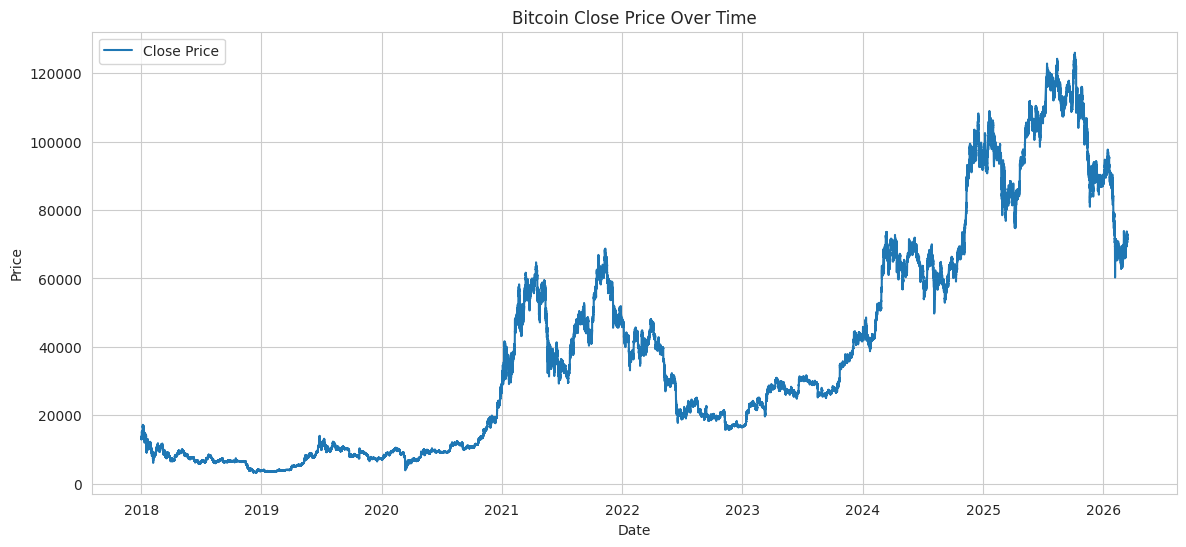

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.title("Bitcoin Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

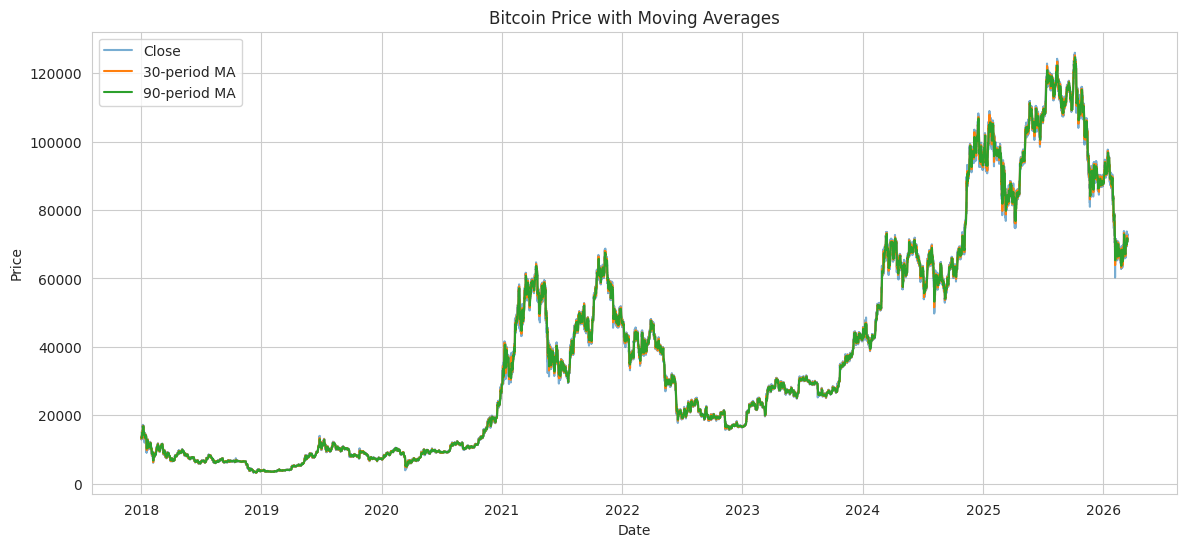

In [25]:
# Moving averages
df["MA_30"] = df["Close"].rolling(window=30).mean()
df["MA_90"] = df["Close"].rolling(window=90).mean()

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.6)
plt.plot(df["Date"], df["MA_30"], label="30-period MA")
plt.plot(df["Date"], df["MA_90"], label="90-period MA")
plt.title("Bitcoin Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## 5) Return Analysis

In [27]:
df["daily_return"] = df["Close"].pct_change()


df[["Date", "Close", "daily_return", "log_return"]].head(10)

,Date,Close,daily_return,log_return
0,2018-01-01 00:00:00,"13,556.150000",NaN,NaN
1,2018-01-01 00:15:00,"13,521.120000",-0.002584,-0.002587
2,2018-01-01 00:30:00,"13,470.410000",-0.003750,-0.003757
3,2018-01-01 00:45:00,"13,529.010000",0.004350,0.004341
4,2018-01-01 01:00:00,"13,445.630000",-0.006163,-0.006182
5,2018-01-01 01:15:00,"13,560.000000",0.008506,0.008470
6,2018-01-01 01:30:00,"13,440.010000",-0.008849,-0.008888
7,2018-01-01 01:45:00,"13,203.060000",-0.017630,-0.017787
8,2018-01-01 02:00:00,"13,387.000000",0.013932,0.013835
9,2018-01-01 02:15:00,"13,225.000000",-0.012101,-0.012175


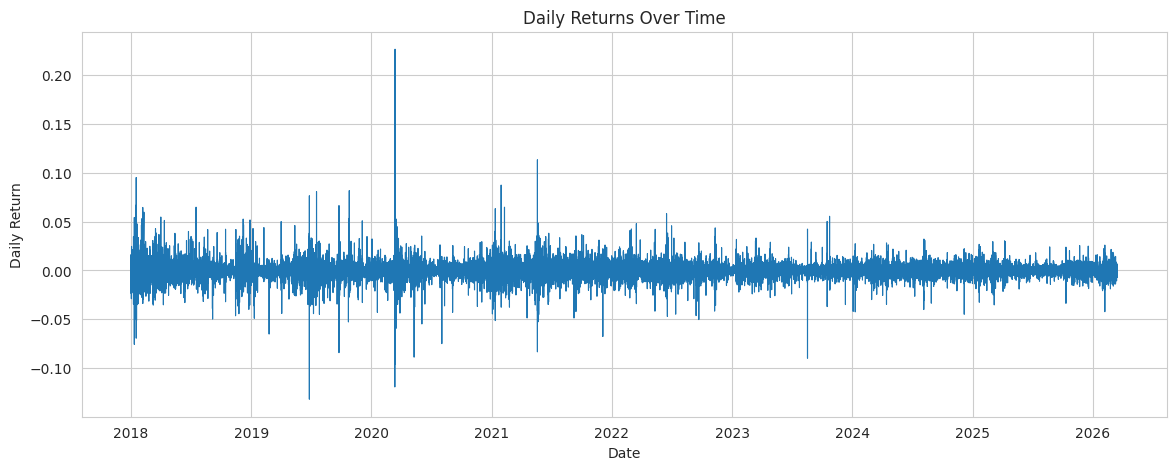

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["daily_return"], linewidth=0.8)
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

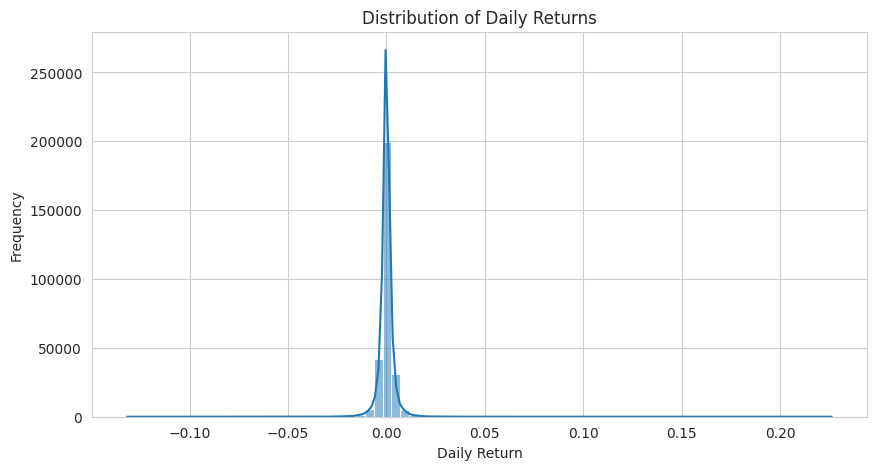

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(df["daily_return"].dropna(), bins=80, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## 6) Volatility Analysis

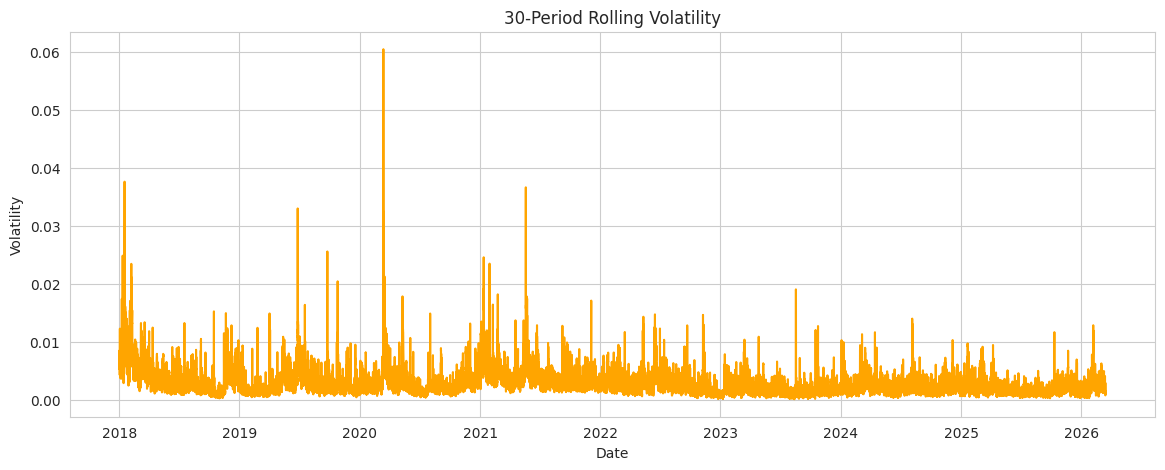

In [30]:
# Rolling volatility
df["volatility_30"] = df["daily_return"].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["volatility_30"], color="orange")
plt.title("30-Period Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

## 7) Volume and Market Activity Analysis

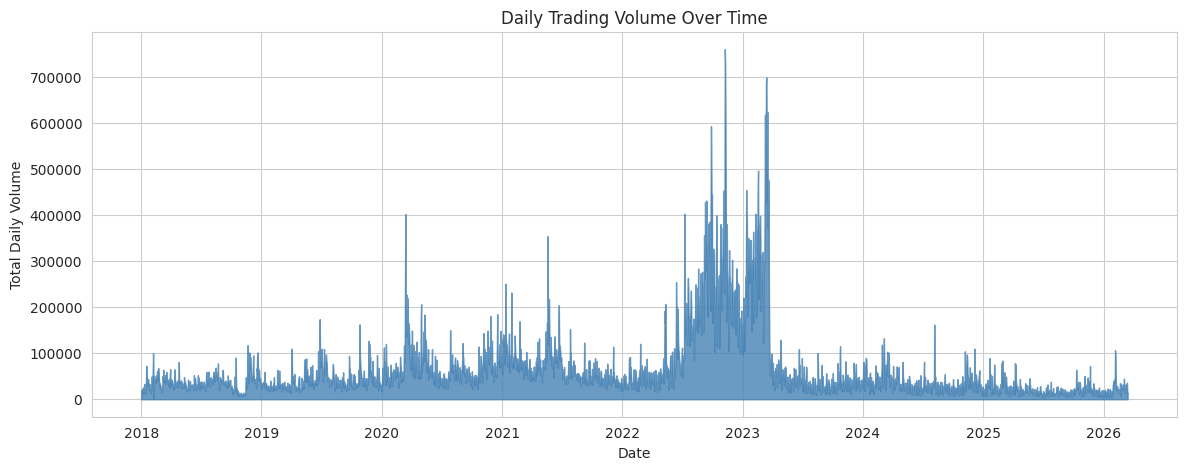

In [36]:
plt.figure(figsize=(14, 5))

daily_volume = df.groupby(df['Date'].dt.date)['Volume'].sum()

# fill_between creates a solid shape under the line
plt.fill_between(daily_volume.index, daily_volume.values, color="steelblue", alpha=0.8)
plt.title("Daily Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Volume")
plt.show()

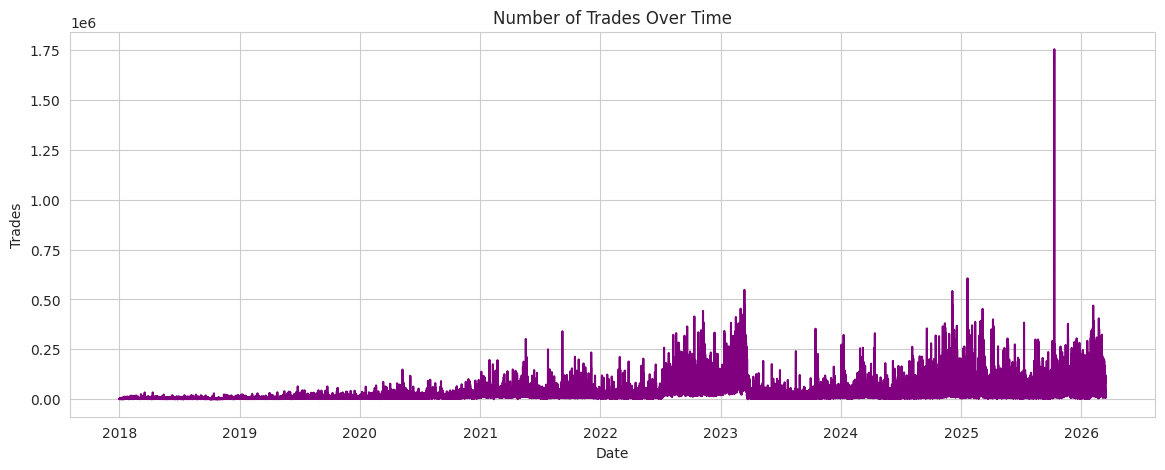

In [38]:
if "Number of trades" in df.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(df["Date"], df["Number of trades"], color="purple")
    plt.title("Number of Trades Over Time")
    plt.xlabel("Date")
    plt.ylabel("Trades")
    plt.show()

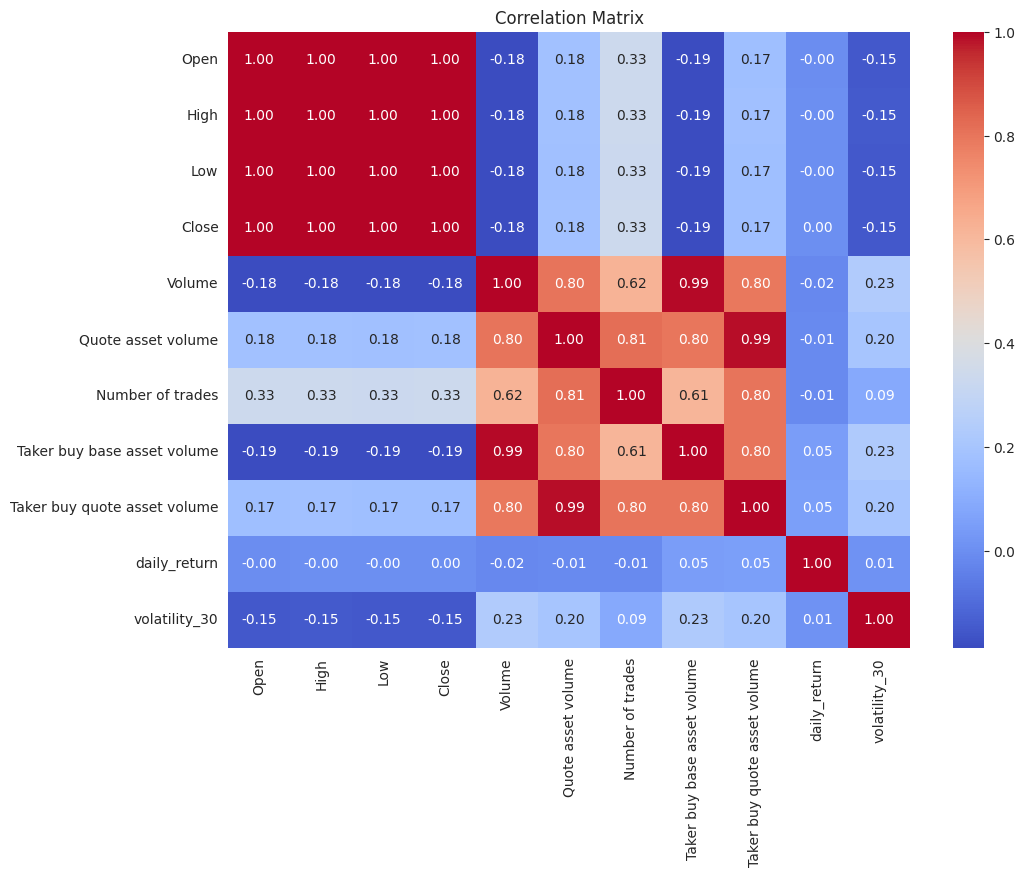

,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,daily_return,volatility_30
Open,1.000000,0.999994,0.999993,0.999990,-0.183854,0.180627,0.333296,-0.186410,0.173122,-0.002351,-0.150151
High,0.999994,1.000000,0.999987,0.999994,-0.183060,0.182051,0.334435,-0.185508,0.174755,-0.000634,-0.149073
Low,0.999993,0.999987,1.000000,0.999994,-0.184808,0.178891,0.331901,-0.187210,0.171679,-0.000510,-0.151250
Close,0.999990,0.999994,0.999994,1.000000,-0.183911,0.180531,0.333191,-0.186260,0.173426,0.000911,-0.150134
Volume,-0.183854,-0.183060,-0.184808,-0.183911,1.000000,0.803041,0.619829,0.992970,0.795527,-0.015991,0.231805
Quote asset volume,0.180627,0.182051,0.178891,0.180531,0.803041,1.000000,0.814594,0.796584,0.986853,-0.014726,0.201122
Number of trades,0.333296,0.334435,0.331901,0.333191,0.619829,0.814594,1.000000,0.614824,0.802088,-0.013862,0.089975
Taker buy base asset volume,-0.186410,-0.185508,-0.187210,-0.186260,0.992970,0.796584,0.614824,1.000000,0.803478,0.045208,0.228170
Taker buy quote asset volume,0.173122,0.174755,0.171679,0.173426,0.795527,0.986853,0.802088,0.803478,1.000000,0.051883,0.198077
daily_return,-0.002351,-0.000634,-0.000510,0.000911,-0.015991,-0.014726,-0.013862,0.045208,0.051883,1.000000,0.010926


In [39]:
# Correlation matrix
corr_candidates = [
    "Open", "High", "Low", "Close", "Volume",
    "Quote asset volume", "Number of trades",
    "Taker buy base asset volume", "Taker buy quote asset volume",
    "daily_return", "volatility_30"
]
corr_cols = [c for c in corr_candidates if c in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


corr

## 8) Drawdown Analysis

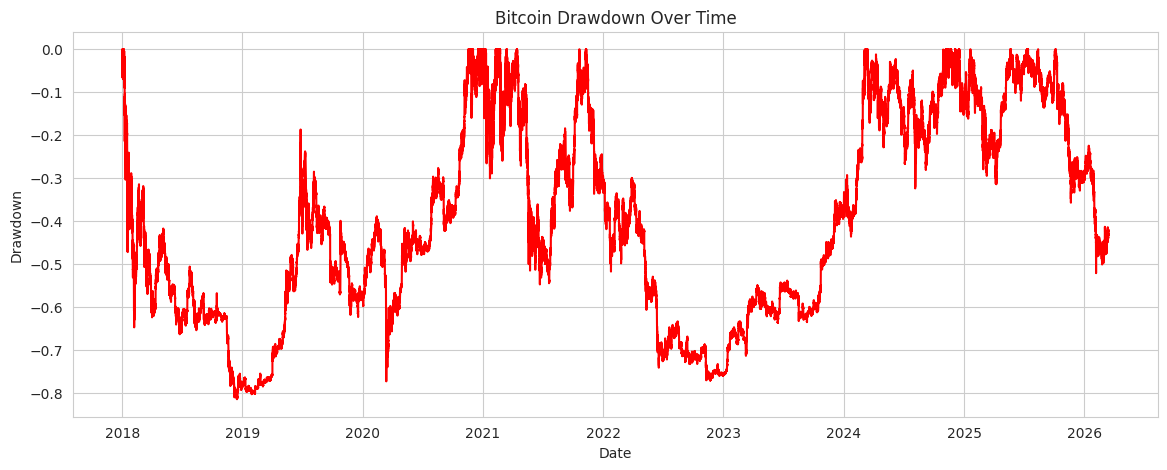

Maximum Drawdown: -0.8155889407050321


In [40]:
df["cum_max"] = df["Close"].cummax()
df["drawdown"] = (df["Close"] - df["cum_max"]) / df["cum_max"]

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["drawdown"], color="red")
plt.title("Bitcoin Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

print("Maximum Drawdown:", df["drawdown"].min())

## 9) Key Summary Statistics

In [41]:
summary = {
    "Start Date": df["Date"].min(),
    "End Date": df["Date"].max(),
    "Start Close": df.loc[df["Date"].idxmin(), "Close"],
    "End Close": df.loc[df["Date"].idxmax(), "Close"],
    "Mean Daily Return": df["daily_return"].mean(),
    "Median Daily Return": df["daily_return"].median(),
    "Daily Return Std": df["daily_return"].std(),
    "Max Daily Gain": df["daily_return"].max(),
    "Max Daily Loss": df["daily_return"].min(),
    "Avg 30-Period Volatility": df["volatility_30"].mean(),
    "Max Drawdown": df["drawdown"].min(),
}

if "Number of trades" in df.columns:
    summary["Average Number of Trades"] = df["Number of trades"].mean()

if "Quote asset volume" in df.columns:
    summary["Average Quote Asset Volume"] = df["Quote asset volume"].mean()

pd.Series(summary)

Start Date                    2018-01-01 00:00:00
End Date                      2026-03-15 23:15:00
Start Close                         13,556.150000
End Close                           72,479.040000
Mean Daily Return                        0.000013
Median Daily Return                      0.000013
Daily Return Std                         0.003740
Max Daily Gain                           0.226288
Max Daily Loss                          -0.131720
Avg 30-Period Volatility                 0.002930
Max Drawdown                            -0.815589
Average Number of Trades            21,265.912150
Average Quote Asset Volume      19,239,554.842423
dtype: object

## 10) Final Notes

This notebook provides **analysis** and interpretation-ready metrics for Bitcoin market behavior.

Possible extensions (still analysis-focused):
- Monthly/quarterly seasonality analysis
- Compare Bitcoin against another asset (e.g., ETH, S&P 500)
- Event window analysis around major macro news dates